In [ ]:
### Build a basic chatbot with GRAPH API


In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage


In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8192")


In [4]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


In [5]:
graph_builder = StateGraph(State)
graph_builder.add_node("llamabot", chatbot)
graph_builder.add_edge(START, "llamabot")
graph_builder.add_edge("llamabot", END)

graph = graph_builder.compile()


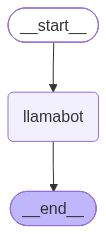

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [ ]:
graph.invoke({"messages": [HumanMessage(content="Hi")]})


In [7]:
for event in graph.stream({"messages": [HumanMessage(content="Hi How are you?")]}):
    for value in event.values():
        print(value["messages"][-1].content)


NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.1-8192` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

In [8]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")


{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [9]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b

    Args:
        a(int): first int
        b(int): second int

    Returns:
        int: output int
    """
    return a * b


In [ ]:
tools = [tool, multiply]


In [ ]:
llm_with_tool = llm.bind_tools(tools)
llm_with_tool


In [10]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()


NameError: name 'tools' is not defined

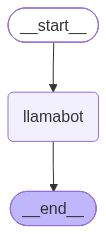

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [ ]:
response = graph.invoke({"messages": [HumanMessage(content="What is the recent AI news")]})


In [ ]:
response['messages'][-1].content


In [12]:
for m in response['messages']:
    m.pretty.print()


NameError: name 'response' is not defined

In [13]:
response = graph.invoke({"messages": [HumanMessage(content="What is 5 multiplied by 2")]} )
for m in response['messages']:
    m.pretty.print()


NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.1-8192` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

In [14]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile(checkpointer=memory)


NameError: name 'tools' is not defined

In [17]:
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": [HumanMessage(content="My name is ___")]} , config=config)
response


NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.1-8192` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}

In [16]:
response['messages'][-1].content


NameError: name 'response' is not defined

In [15]:
response = graph.invoke({"messages": [HumanMessage(content="Hey whats my name")]} , config=config)

print(response['messages'][-1].content)


NameError: name 'config' is not defined